In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random # pour faire des tirages aléatoires

In [26]:
# 0) En Colab, habilita widgets
from google.colab import output
output.enable_custom_widget_manager()

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [27]:
#%% Fonction utilisées dans le script
# Fonction de lecture des données
def read_excel_data(filename, sheet_name):
        data = pd.read_excel(filename, sheet_name=sheet_name, header=None)
        values =  data.values
        return values

# Modèle algébrique de production PV
def Mod_PVprod(Ta, E, Ppv_nom):

    # Paramètre du modèle
    NOCT = 48.
    E_ref = 1000. # Rayonnement de référence [W/m²]
    Tpv_ref = 25. # Température de référence [°C]
    alpha = -4.8e-3

    # à remplir ...
    # (2) Température des modules
    Tpv = Ta + E * (NOCT - 20.0) / 800.0

    # (1) Puissance PV
    Ppv = (E / E_ref) * (Ppv_nom + alpha * (Tpv - Tpv_ref))

    return Ppv

In [28]:
#%% Paramètres du problème
# Constantes :
deg2K  = 273.15 # Conversion degré en Kelvin
kW2W = 1000. # Conversion kW en W
kWh2Wh = 1000.
h2min = 60 # conversion h -> min
N_ev = 50
capa_bat = 52  # Capacité des batteries [kWh]
d_autonomie = 320 # Autonomie des batteries [km]
P1_ch = 22 # Puissance de recharge [kW] --> Hypothese: recharge normal
vmoy = 40/h2min # Vitesse moyenne en km par min

Ppv_nom = 500e3 # Puissance nominale de l'installation solaire

In [29]:
#%% Chargement des données
j = 174 # Jour de simulation
Nj = 7 # Nombre de jour de simu
ind_0 = j*24+1 # commence à 1h
ind_f = (j+Nj)*24 + 1 # termine à minuit

In [30]:
filename = 'TP-V2G-Input_data.xlsx'
sheet_name = "Demands"
Hd = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,1].tolist())*kW2W
Pd = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,2].tolist())*kW2W
v_tps_h = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,0].tolist())*h2min

sheet_name = "Meteo"
E = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,1].tolist())
Ta = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,2].tolist())

#%% On passe au pas de temps de la minute
v_tps_mn = np.arange(v_tps_h[0],v_tps_h[-1], 1)

Pd_mn = np.interp(v_tps_mn, v_tps_h, Pd)
E_mn = np.interp(v_tps_mn, v_tps_h, E)
Ta_mn = np.interp(v_tps_mn, v_tps_h, Ta)

del E, Hd, Pd, v_tps_h, Ta
#%% Production PV
Ppv = Mod_PVprod(Ta_mn, E_mn, Ppv_nom)

In [31]:
def simulate_unidirectional(cap_factor_weekday=0.5, k_need_weekday=0.5):
    #%% Demande EV — pilotage basé sur PV (sans soustraction Pd, comme prévu)
    P_ev = np.zeros(len(Pd_mn))  # W

    # Paramètres (respectez vos échelles)
    cons_kWh_km = capa_bat / d_autonomie  # kWh/km
    Pmax_W = P1_ch * kW2W                 # 22 kW par véhicule (en W)
    dt_h = 1.0 / 60.0                     # 1 min
    soc_min = 0.10
    soc_max = 1.00

    rng = np.random.default_rng(174)

    # début : jour 174 est lundi et TOUS commencent à 100%
    E_bat = np.ones(N_ev) * (soc_max * capa_bat)  # kWh

    # minuit environ (votre série commence à 1h => -60)
    t0_midnight = v_tps_mn[0] - 60

    def is_weekend(day_from_174):
        # 0..4 weekdays, 5 samedi, 6 dimanche
        return day_from_174 >= 5

    for d in range(Nj):
        day_midnight = t0_midnight + d * 1440
        i_day0 = np.searchsorted(v_tps_mn, day_midnight, side="left")
        i_day1 = np.searchsorted(v_tps_mn, day_midnight + 1440, side="left")
        if i_day1 <= i_day0:
            continue

        weekend = is_weekend(d)
        cap_factor = 1.0 if weekend else cap_factor_weekday

        # ----------------------
        # 1) Mobilité du jour
        # ----------------------
        if weekend:
            # finde: connectés toute la journée, sans commutation
            E_day = np.zeros(N_ev)  # kWh
            arr_idx = np.full(N_ev, i_day0)
            dep_idx = np.full(N_ev, i_day1)
        else:
            # weekdays: randomisation semblable à la tienne
            hdep_home = rng.triangular(7.5, 8.5, 9.5, size=N_ev)
            d_traj = rng.triangular(10.0, 30.0, 50.0, size=N_ev)

            t_traj_h = (d_traj / (vmoy * 60.0))  # vmoy*60 = km/h
            harr_work = hdep_home + t_traj_h

            hdep_work = rng.triangular(17.0, 18.0, 19.0, size=N_ev)
            hdep_work = np.maximum(hdep_work, harr_work + 0.25)

            E_day = 2.0 * d_traj * cons_kWh_km  # kWh dépensé aller-retour

            arr_min = day_midnight + np.round(harr_work * 60.0).astype(int)
            dep_min = day_midnight + np.round(hdep_work * 60.0).astype(int)
            arr_idx = np.searchsorted(v_tps_mn, arr_min, side="left")
            dep_idx = np.searchsorted(v_tps_mn, dep_min, side="left")

        # Appliquer la dépense du commute (y respecter le SOC minimum)
        E_bat -= E_day
        E_bat = np.clip(E_bat, soc_min * capa_bat, soc_max * capa_bat)

        # ----------------------
        # 2) Objectif de charge
        # ----------------------
        if weekend:
            # finde : retour à 100%
            E_need = (soc_max * capa_bat) - E_bat
        else:
            # weekdays : récupérer SEULEMENT 50% de ce qui a été perdu ce jour-là
            E_need = k_need_weekday * E_day

        E_need = np.maximum(E_need, 0.0)
        E_rem = E_need.copy()

        # ----------------------
        # 3) Charge minute par minute (cap avec PV et redistribution)
        # ----------------------
        for t in range(i_day0, i_day1):
            pv_W = max(Ppv[t], 0.0)
            if pv_W <= 0:
                continue

            # Votre règle : demande totale EV <= cap_factor * Ppv
            P_total_allowed = cap_factor * pv_W
            if P_total_allowed <= 0:
                continue

            plugged = (t >= arr_idx) & (t < dep_idx) & (E_rem > 1e-9) & (E_bat < soc_max * capa_bat - 1e-9)
            active = np.where(plugged)[0]
            if active.size == 0:
                continue

            # puissance maximale par véhicule selon les besoins + limite de chargeur
            P_need_W = (E_rem[active] / dt_h) * 1000.0  # W
            P_cap_i = np.minimum(Pmax_W, P_need_W)

            # water-filling: ne gaspille pas de puissance si certains saturent
            P_alloc = np.zeros(active.size)
            remaining = P_total_allowed
            alive = np.ones(active.size, dtype=bool)

            while remaining > 1e-6 and alive.any():
                idx_local = np.where(alive)[0]
                share = remaining / idx_local.size
                give = np.minimum(share, P_cap_i[idx_local] - P_alloc[idx_local])
                P_alloc[idx_local] += give
                remaining -= give.sum()
                alive[idx_local] = (P_alloc[idx_local] < P_cap_i[idx_local] - 1e-9)

            P_ev[t] += P_alloc.sum()

            dE = (P_alloc / 1000.0) * dt_h  # kWh
            E_rem[active] = np.maximum(E_rem[active] - dE, 0.0)
            E_bat[active] = np.clip(E_bat[active] + dE, soc_min * capa_bat, soc_max * capa_bat)

    return P_ev

In [32]:
def lissage_index_variations_rapides(P_grid):
    """Indice lissage basé sur variations rapides: mean((P(t)-P(t-1))^2)."""
    dP = np.diff(P_grid)
    return np.mean(dP**2)

def plot_scenario(cap_factor_weekday=0.5, k_need_weekday=0.5):
    P_ev = simulate_unidirectional(cap_factor_weekday, k_need_weekday)

    # Simulation
    P_ev = simulate_unidirectional(
        cap_factor_weekday=cap_factor_weekday,
        k_need_weekday=k_need_weekday
    )

    # Puissance affichée par réseau
    P_grid = Pd_mn + P_ev - Ppv

    # Índice de lissage
    dP = np.diff(P_grid)
    J = np.mean(dP**2)

    # Plot
    plt.figure(figsize=(18, 5), dpi=120)

    plt.plot(v_tps_mn, Pd_mn, color="red", label="$P_d$")
    plt.plot(v_tps_mn, Ppv,   color="orange", label="$P_{pv}$")
    plt.plot(v_tps_mn, P_ev,  color="blue", label="$P_{ev}$ (piloté)")

    plt.title(
        f"Unidirectional — cap_factor={cap_factor_weekday:.2f}, "
        f"k_need={k_need_weekday:.2f} | Lissage={J:.3e}"
    )

    plt.ylabel("Puissance [W]")
    plt.xlabel("Temps [min]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [33]:
# --- Sliders
cap_slider = widgets.FloatSlider(
    value=0.50, min=0.00, max=1.50, step=0.05,
    description='cap_factor', continuous_update=False
)

kneed_slider = widgets.FloatSlider(
    value=0.50, min=0.00, max=1.00, step=0.05,
    description='k_need', continuous_update=False
)

ui = widgets.VBox([cap_slider, kneed_slider])

out = widgets.interactive_output(
    plot_scenario,
    {'cap_factor_weekday': cap_slider, 'k_need_weekday': kneed_slider}
)

display(ui, out)

Output()

Output()

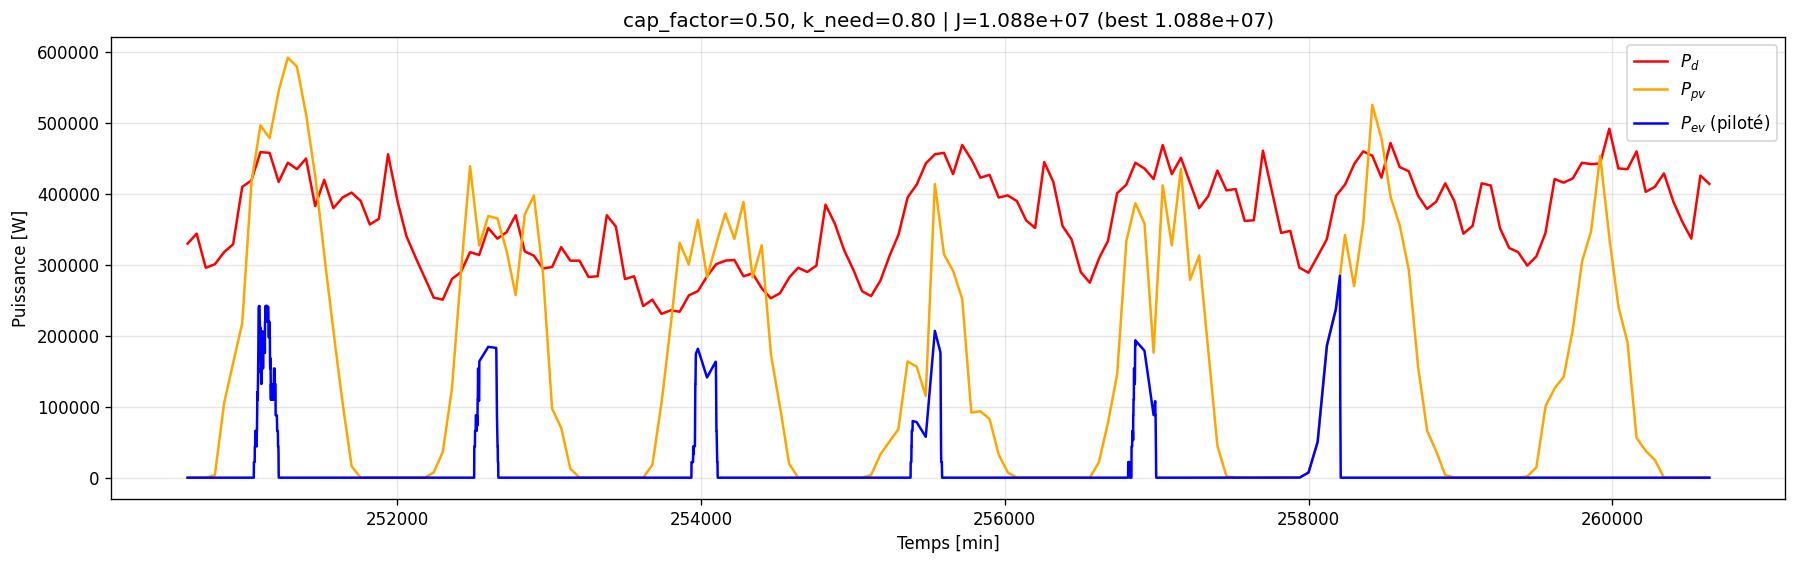

cap: 0.5 k_need: 0.8


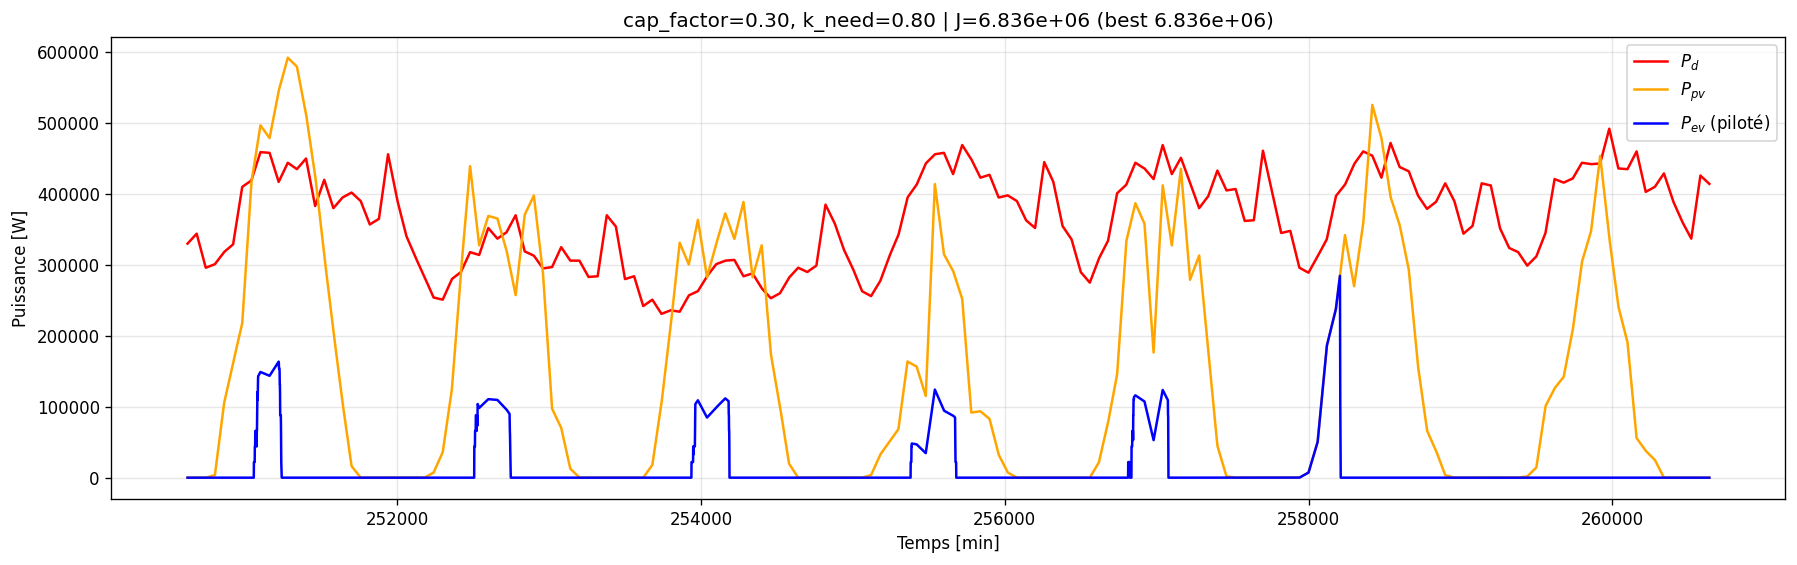

cap: 0.3 k_need: 0.8


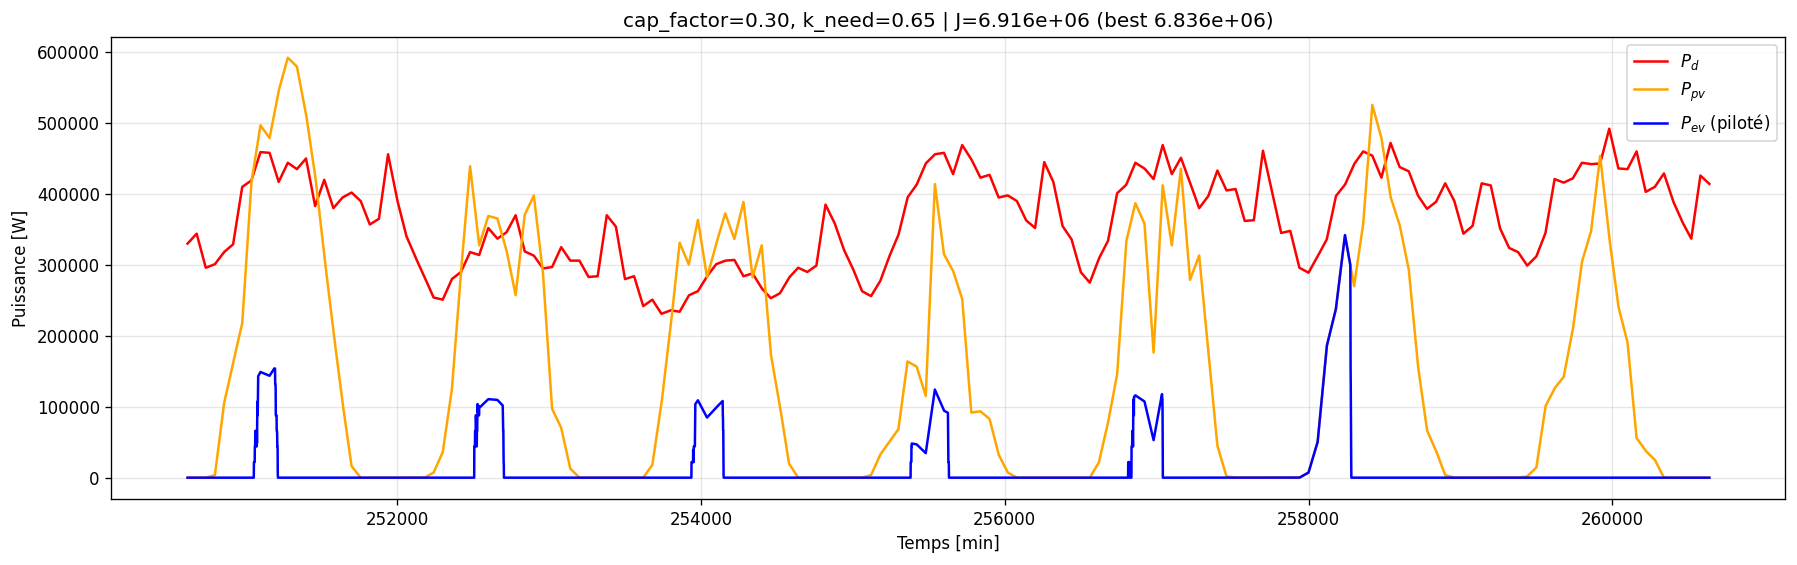

cap: 0.3 k_need: 0.65


In [34]:
# -------- Sliders 2
cap_slider = widgets.FloatSlider(
    value=0.50, min=0.00, max=1.50, step=0.05,
    description='cap_factor', continuous_update=False
)
kneed_slider = widgets.FloatSlider(
    value=0.50, min=0.00, max=1.00, step=0.05,
    description='k_need', continuous_update=False
)

ui = widgets.VBox([cap_slider, kneed_slider])

# -------- Outputs (un pour le plot, un autre pour le texte)
out_plot = widgets.Output()
out_info = widgets.Output()

# -------- Meilleur état trouvé
best = {
    "J": np.inf,
    "cap_factor": None,
    "k_need": None
}

def compute_lissage(P_grid):
    dP = np.diff(P_grid)
    return float(np.mean(dP**2))  # J = mean(ΔP^2)

def update_all(change=None):
    cap = float(cap_slider.value)
    kne = float(kneed_slider.value)

    # simulation
    P_ev = simulate_unidirectional(cap_factor_weekday=cap, k_need_weekday=kne)
    P_grid = Pd_mn + P_ev - Ppv

    # Index lissage
    J = compute_lissage(P_grid)

    # Mettre à jour best-so-far
    improved = False
    if J < best["J"]:
        best["J"] = J
        best["cap_factor"] = cap
        best["k_need"] = kne
        improved = True

    # ----- Text
    with out_info:
        out_info.clear_output(wait=True)
        print(f"Scenario actuel  : cap_factor={cap:.2f}, k_need={kne:.2f}")
        print(f"Lissage J        : {J:.3e}")
        print("-" * 40)
        print(f"Meilleur trouvé  : cap_factor={best['cap_factor']:.2f}, k_need={best['k_need']:.2f}")
        print(f"J_min            : {best['J']:.3e}")
        if improved:
            print("✅ Nouveau meilleur scénario !")

    # ----- Plot
    with out_plot:
        out_plot.clear_output(wait=True)
        plt.figure(figsize=(18,5), dpi=120)
        plt.plot(v_tps_mn, Pd_mn, color="red", label="$P_d$")
        plt.plot(v_tps_mn, Ppv,   color="orange", label="$P_{pv}$")
        plt.plot(v_tps_mn, P_ev,  color="blue", label="$P_{ev}$ (piloté)")
        plt.title(f"cap_factor={cap:.2f}, k_need={kne:.2f} | J={J:.3e} (best {best['J']:.3e})")
        plt.xlabel("Temps [min]")
        plt.ylabel("Puissance [W]")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# Connecte les événements
cap_slider.observe(update_all, names='value')
kneed_slider.observe(update_all, names='value')

# Afficher l’interface utilisateur + première mise à jour
display(ui, out_info, out_plot)
update_all()

In [35]:
def test(change=None):
    print("cap:", cap_slider.value, "k_need:", kneed_slider.value)

cap_slider.observe(test, names='value')
kneed_slider.observe(test, names='value')

In [36]:
P_ev = simulate_unidirectional(
    cap_factor_weekday=cap_slider.value,
    k_need_weekday=kneed_slider.value
)

print("max Pev (kW):", P_ev.max()/1000)

max Pev (kW): 341.99994405427196


In [37]:
def is_weekend(d):
    # 0 = lundi
    return d % 7 in [5, 6]   # samedi et dimanche

t0_midnight = v_tps_mn[0] - (v_tps_mn[0] % 1440)

P_ev = simulate_unidirectional(
    cap_factor_weekday=cap_slider.value,
    k_need_weekday=kneed_slider.value
)

for d in range(Nj):
    day0 = np.searchsorted(v_tps_mn, t0_midnight + d*1440, side="left")
    day1 = np.searchsorted(v_tps_mn, t0_midnight + (d+1)*1440, side="left")
    ratio = np.max(P_ev[day0:day1] / np.maximum(Ppv[day0:day1], 1e-9))
    print(d, "weekend" if is_weekend(d) else "weekday", "max(Pev/Ppv)=", ratio)

0 weekday max(Pev/Ppv)= 0.49999999999999994
1 weekday max(Pev/Ppv)= 0.5000000000000002
2 weekday max(Pev/Ppv)= 0.5000000000000001
3 weekday max(Pev/Ppv)= 0.5000000000000002
4 weekday max(Pev/Ppv)= 0.5000000000000001
5 weekend max(Pev/Ppv)= 1.0000000000000007
6 weekend max(Pev/Ppv)= 0.0


In [38]:
surplus = np.maximum(Ppv - Pd_mn, 0)
print("max surplus (kW):", surplus.max()/1000)
print("energía surplus semanal (kWh):", surplus.sum()/1000 * (1/60))

max surplus (kW): 148.19978081588366
energía surplus semanal (kWh): 1448.0562285088013


In [39]:
print("max Pev (kW):", P_ev.max()/1000)

max Pev (kW): 341.99994405427196


In [40]:
print("max Pd (kW):", Pd_mn.max()/1000)
print("max Ppv (kW):", Ppv.max()/1000)
print("max Pev (kW):", P_ev.max()/1000)

max Pd (kW): 492.0
max Ppv (kW): 592.1997808158836
max Pev (kW): 341.99994405427196


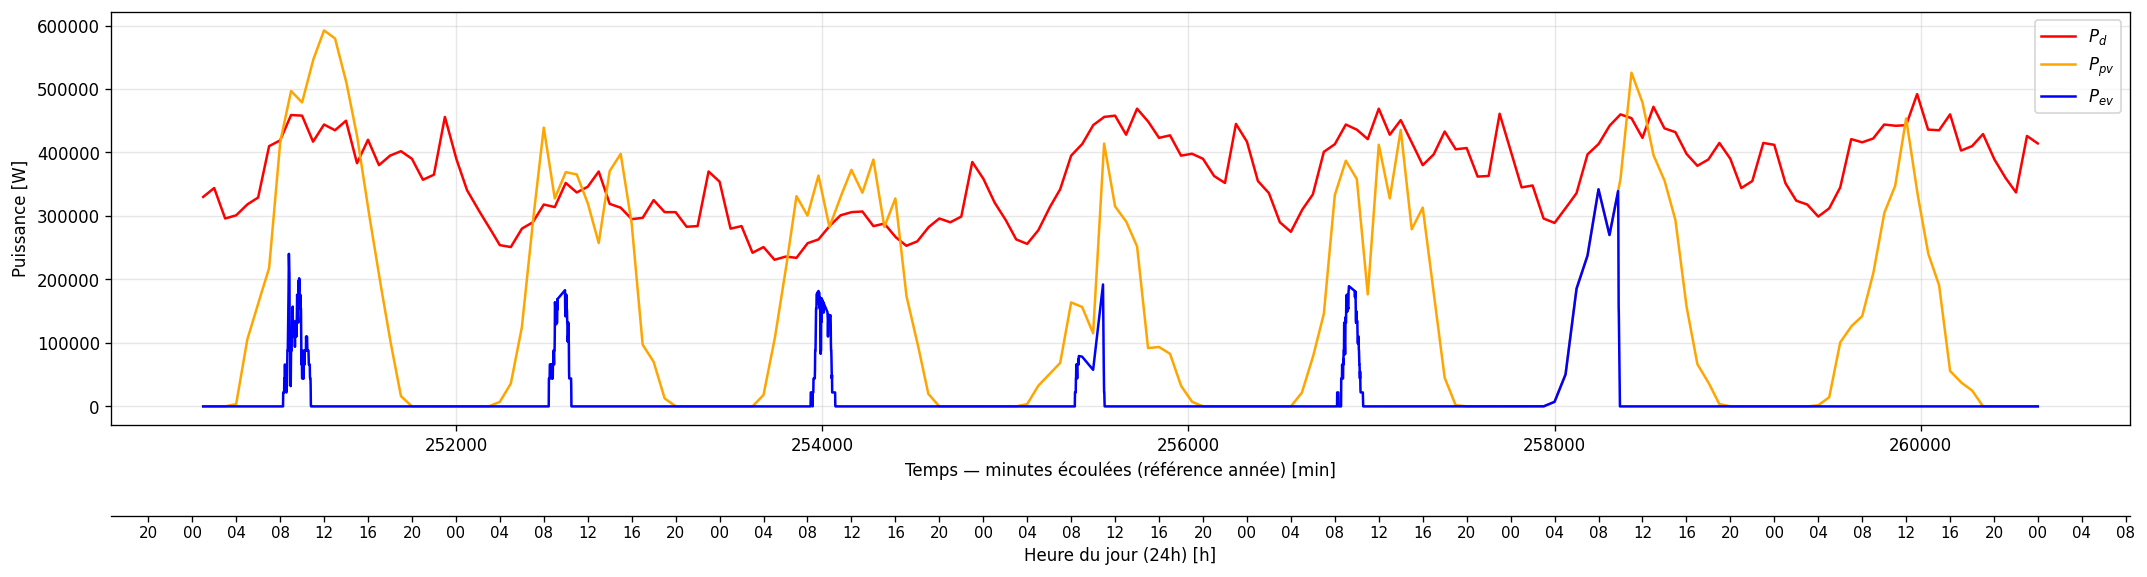

In [41]:
import matplotlib.ticker as mticker

#%% Représentation graphique (mêmes unités : W)
fig, ax = plt.subplots(figsize=(18, 5), dpi=120)

ax.plot(v_tps_mn, Pd_mn, color="red",    label="$P_d$")
ax.plot(v_tps_mn, Ppv,   color="orange", label="$P_{pv}$")
ax.plot(v_tps_mn, P_ev,  color="blue",   label="$P_{ev}$")

ax.set_ylabel("Puissance [W]")
ax.set_xlabel("Temps — minutes écoulées (référence année) [min]")
ax.legend()
ax.grid(True, alpha=0.3)

# --- définit ceci une fois (référence minuit du premier jour affiché)
t0_midnight = v_tps_mn[0] - 60  # parce que ta série commence une heure


# === SUB-EJE X (abajo) annexe un banc réel y ticks cada 4h ===
ax_h = ax.secondary_xaxis(-0.22, functions=(lambda x: x, lambda x: x))
ax_h.set_xlabel("Heure du jour (24h) [h]")

# Plage visible de l’axe X principal (minutes absolues de l’année)
xmin, xmax = ax.get_xlim()

# Moment "réel" avant ou après un xmin (multiplo de 1440 min)
midnight0 = np.floor(xmin / 1440.0) * 1440.0

# Ticks toutes les 4 heures = 240 min, à partir de midnight0
ticks = np.arange(midnight0, xmax + 1, 240.0)

# Nous restons seuls avec les tiques dans la plage visible
ticks = ticks[(ticks >= xmin) & (ticks <= xmax)]

ax_h.set_xticks(ticks)

# Étiquettes : heure du jour (00,04,08,...), répété chaque jour
def hour_label(x, pos):
    h = int((x % 1440) / 60)   # 0..23
    return f"{h:02d}"

ax_h.xaxis.set_major_formatter(mticker.FuncFormatter(hour_label))
ax_h.tick_params(axis="x", labelsize=9, pad=2)



plt.tight_layout()
plt.show()